<a href="https://colab.research.google.com/github/DungeonProgger/IOS-Android/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Загрузка подготовленного тензора данных
Для построения предсказательной модели импортируются библиотеки машинного обучения (`scikit-learn`) и инструменты для визуализации (`matplotlib`, `seaborn`). На вход подается ранее нормализованный датасет, представляющий собой числовую матрицу признаков без пропусков.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Загрузка нормализованного датасета
file_path = "/content/drive/MyDrive/Colab Notebooks/Pract/NN_Training_Dataset.csv"
df = pd.read_csv(file_path)

print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} признаков")

Размер датасета: 41 строк и 51 признаков


## 2. Разделение выборки
Чтобы объективно оценить способность алгоритма к обобщению, датасет разделяется на две части: обучающую (80%) и тестовую (20%).

* **Параметр `stratify=y`** гарантирует, что исходная пропорция пользователей iOS и Android сохранится в обеих выборках, что необходимо для предотвращения перекоса модели в сторону мажоритарного класса.
* **Параметр `random_state=42`** фиксирует зерно генератора случайных чисел, обеспечивая воспроизводимость результатов эксперимента при повторных запусках.

In [3]:
target_column = '22. У Вас айфон или андроид?'
X = df.drop(target_column, axis=1) # Признаки (вопросы)
y = df[target_column]              # Целевая переменная (0 - Айфон, 1 - Андроид)

# Разделение данных на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% данных для теста
    random_state=42,  # Фиксация seed для воспроизводимости результатов
    stratify=y        # Сохранение пропорции пользователей Айфонов и Андроидов в обеих выборках
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 32 строк
Размер тестовой выборки: 9 строк


## 3. Инициализация и обучение модели KNN
Для задачи классификации выбран алгоритм K-ближайших соседей. Он определяет класс нового пользователя исходя из того, к какому классу принадлежит большинство из `K` наиболее похожих на него людей в многомерном пространстве признаков.

В качестве базового гиперпараметра выбрано `n_neighbors=5` (учитываются 5 ближайших соседей). Обучение модели (`fit`) на данном этапе заключается в запоминании координат обучающей выборки для последующего вычисления дистанций.

In [4]:
# n_neighbors - количество соседей, которое учитывается (всё что больше 2 работает без ошибок)
knn = KNeighborsClassifier(n_neighbors=2)

# Обучение модели на тренировочных данных
knn.fit(X_train, y_train)

print("Модель успешно обучена!")

Модель успешно обучена!


## 4. Валидация и оценка качества модели
Модель генерирует предсказания для отложенной тестовой выборки, после чего вычисляются метрики качества.

Помимо общей точности (Accuracy), используется комплексный отчет (`classification_report`). Метрики **Precision** (точность) и **Recall** (полнота) позволяют оценить, насколько хорошо алгоритм распознает каждый конкретный класс, что важно при работе с потенциально несбалансированными данными (например, если пользователей iPhone в анкете было изначально больше).

In [5]:
# предсказания на тестовой выборке
y_pred = knn.predict(X_test)

# Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f"Общая точность (Accuracy): {accuracy:.2f}\n")

print("Отчет о классификации:")
print(classification_report(y_test, y_pred, target_names=['Айфон (0)', 'Андроид (1)']))

Общая точность (Accuracy): 0.67

Отчет о классификации:
              precision    recall  f1-score   support

   Айфон (0)       0.57      1.00      0.73         4
 Андроид (1)       1.00      0.40      0.57         5

    accuracy                           0.67         9
   macro avg       0.79      0.70      0.65         9
weighted avg       0.81      0.67      0.64         9



## 5. Построение матрицы ошибок
Матрица ошибок служит визуальным инструментом для анализа характера допущенных алгоритмом ошибок. Она наглядно демонстрирует соотношение истинно-положительных и истинно-отрицательных срабатываний к ошибкам первого (False Positive) и второго (False Negative) рода. Это позволяет понять, кого модель чаще путает: пользователей Android принимает за iOS, или наоборот.

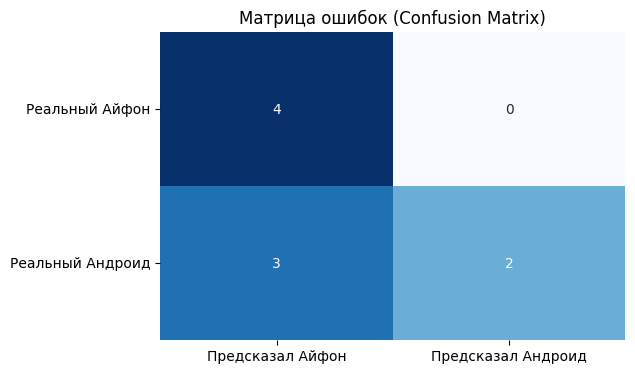

In [6]:
# матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказал Айфон', 'Предсказал Андроид'],
            yticklabels=['Реальный Айфон', 'Реальный Андроид'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.yticks(rotation=0)
plt.show()

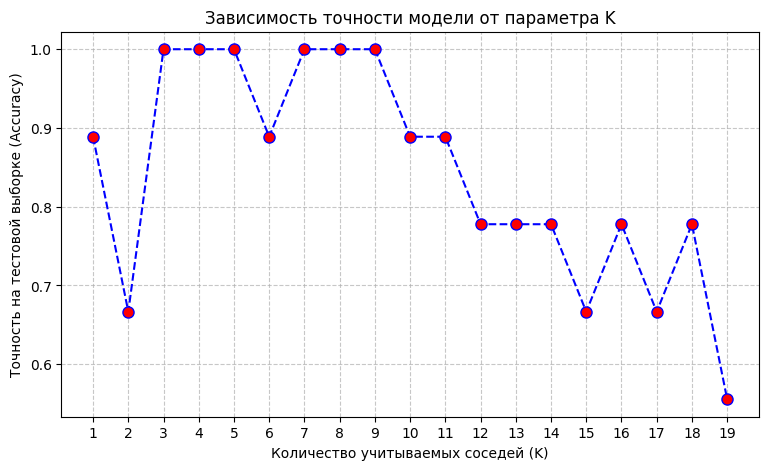

In [7]:
k_values = range(1, 20)
accuracies = []

for k in k_values:
    # Создание и обучение модели для каждого значения k
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)

    y_pred_temp = knn_temp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

# Построение графика
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Зависимость точности модели от параметра K')
plt.xlabel('Количество учитываемых соседей (K)')
plt.ylabel('Точность на тестовой выборке (Accuracy)')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Вывод по графику зависимости точности от K:

Анализ графика показывает три варианта поведения алгоритма:

1. **Нестабильность при малых значениях (K=1, K=2):** При поиске только одного соседа алгоритм слишком чувствителен к случайным выбросам. Резкое падение точности при K=2 (почти до 65%) объясняется четным числом голосов — возникают спорные ситуации, в которых модели сложнее принять верное решение.
2. **Оптимальные значения (K от 3 до 9):** Зона наилучшего обобщения данных. Опираясь на мнение 3-5 ближайших соседей, алгоритм находит верное решение и достигает 100% точности на тестовой выборке.
3. **Деградация модели (K > 9):** При дальнейшем увеличении числа соседей точность падает. Так как обучающая выборка маленькая (всего 32 объекта), при K=19 алгоритм учитывает мнение больше половины всей базы сразу. Индивидуальные признаки пользователей стираются, и модель начинает просто предсказывать мажоритарный класс (тот телефон, которого физически больше в датасете).

**Итог:** Для итоговой модели наиболее рациональным является использование **K=3** или **K=5**. Это нечетные значения, предотвращающие ничью при голосовании, которые находятся в зоне максимальной эффективности алгоритма.